In [1]:
import pandas as pd

In [3]:
!pip install numpy scikit-learn statsmodels

In [4]:
import sklearn
import statsmodels
import numpy
print("All packages installed successfully")

All packages installed successfully


In [5]:
from nsepy import get_history as gh
import datetime as dt

In [10]:
!pip install yfinance

In [12]:
import yfinance as yf
import pandas as pd
import datetime as dt

start = dt.datetime(2021,7,1)
end = dt.datetime(2022,1,28)

stk_data = yf.download("RELIANCE.NS", start=start, end=end)

print(stk_data.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open      Volume
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS
Date                                                                  
2021-07-01  954.592529  966.058798  953.250218  963.715501    12534407
2021-07-02  968.743286  970.495102  952.317341  954.160145    14086620
2021-07-05  978.366882  979.891169  969.858139  972.110448    11702287
2021-07-06  966.809570  977.775346  964.716550  975.978096    10070124
2021-07-07  960.098083  968.151828  954.615226  968.151828    10454892


In [13]:
stk_data=stk_data[["Open","High","Low","Close"]]

In [14]:
stk_data

Price,Open,High,Low,Close
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,
2021-07-01,963.715501,966.058798,953.250218,954.592529
2021-07-02,954.160145,970.495102,952.317341,968.743286
2021-07-05,972.110448,979.891169,969.858139,978.366882
2021-07-06,975.978096,977.775346,964.716550,966.809570
2021-07-07,968.151828,968.151828,954.615226,960.098083
...,...,...,...,...
2022-01-20,1137.552961,1142.057580,1117.054587,1127.269653
2022-01-21,1115.689680,1138.553979,1115.689680,1127.451660


In [15]:
column="Close"

In [16]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1= Ms.fit_transform(stk_data[[column]])
print("Len:",data1.shape)

Len: (144, 1)


In [17]:
len(data1)

144

In [18]:
training_size = round(len(data1 ) * 0.80)
print(training_size)
X_train=data1[:training_size]
X_test=data1[training_size:]
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
y_train=data1[:training_size]
y_test=data1[training_size:]
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

115
X_train length: (115, 1)
X_test length: (29, 1)
y_train length: (115, 1)
y_test length: (29, 1)


In [20]:
!pip install --upgrade scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.0 MB 6.0 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.0 MB 6.0 MB/s eta 0:00:01
   ------------------- -------------------- 3.9/8.0 MB 6.5 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.0 MB 6.8 MB/s eta 0:00:01
   ---------------------------------- ----- 6.8/8.0 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.0 MB 7.0 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 5.9 MB/s  0:00:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.2
    Uninstalling scikit-learn-1.7.2:
      Successfully uninstalled scikit-learn-1.7.2


  You can safely remove it manually.


In [23]:
from sklearn.metrics import mean_squared_error
import numpy as np

def rmsemape(y_Test,predicted_stock_price_test_ori):
    print("RMSE-Testset:",np.sqrt(mean_squared_error(y_Test,predicted_stock_price_test_ori)))

In [24]:
len(y_pred)

29

In [27]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = np.sqrt(mean_squared_error(y_test, y_pred))
print(mse)

0.09477097261416424


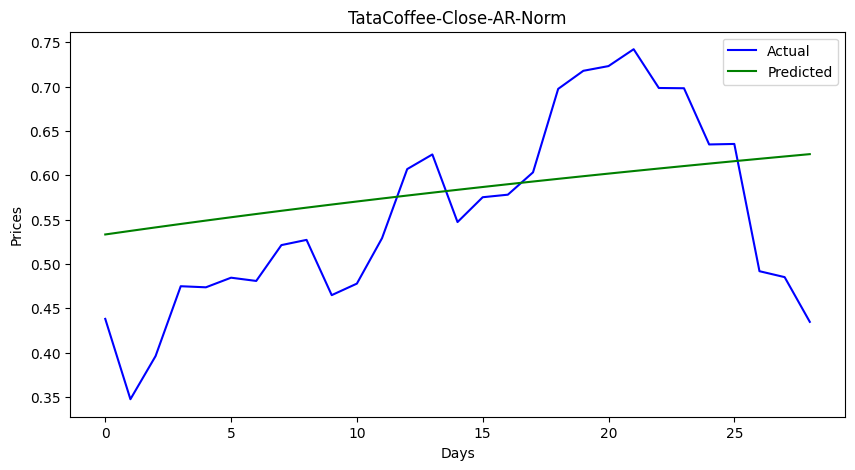

In [28]:
from stockFunctions import graph
graph(y_test,y_pred,"Actual","Predicted","TataCoffee-Close-AR-Norm","Days","Prices")

In [29]:
len(data1)

144

In [30]:
y_test

array([[0.43808805],
       [0.34749816],
       [0.39616667],
       [0.4749119 ],
       [0.47369173],
       [0.48453114],
       [0.48086986],
       [0.52128335],
       [0.52716967],
       [0.46486245],
       [0.47785564],
       [0.52910776],
       [0.6069914 ],
       [0.62350182],
       [0.54726896],
       [0.57526391],
       [0.57813524],
       [0.60333089],
       [0.69743724],
       [0.71782385],
       [0.72313552],
       [0.74215792],
       [0.69844249],
       [0.69815555],
       [0.63477183],
       [0.63534609],
       [0.49185292],
       [0.48517704],
       [0.43471409]])

In [31]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])

In [32]:
aTestNormTable

,Close
0,0.438088
1,0.347498
2,0.396167
3,0.474912
4,0.473692
5,0.484531
6,0.48087
7,0.521283
8,0.52717
9,0.464862


In [33]:
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)

In [34]:
actual_stock_price_test_ori

array([[1064.9329834 ],
       [1036.22155762],
       [1051.64648438],
       [1076.60388184],
       [1076.21716309],
       [1079.65258789],
       [1078.4921875 ],
       [1091.30078125],
       [1093.16638184],
       [1073.41882324],
       [1077.53686523],
       [1093.78063965],
       [1118.46496582],
       [1123.69775391],
       [1099.53662109],
       [1108.40930176],
       [1109.31933594],
       [1117.30480957],
       [1147.1307373 ],
       [1153.59204102],
       [1155.2755127 ],
       [1161.30444336],
       [1147.44934082],
       [1147.35839844],
       [1127.26965332],
       [1127.45166016],
       [1081.97314453],
       [1079.8572998 ],
       [1063.86364746]])

In [35]:
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [36]:
actual_stock_price_test_oriA

,Close
0,1064.932983
1,1036.221558
2,1051.646484
3,1076.603882
4,1076.217163
5,1079.652588
6,1078.492188
7,1091.300781
8,1093.166382
9,1073.418823


In [37]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [38]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,[column])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,[column])

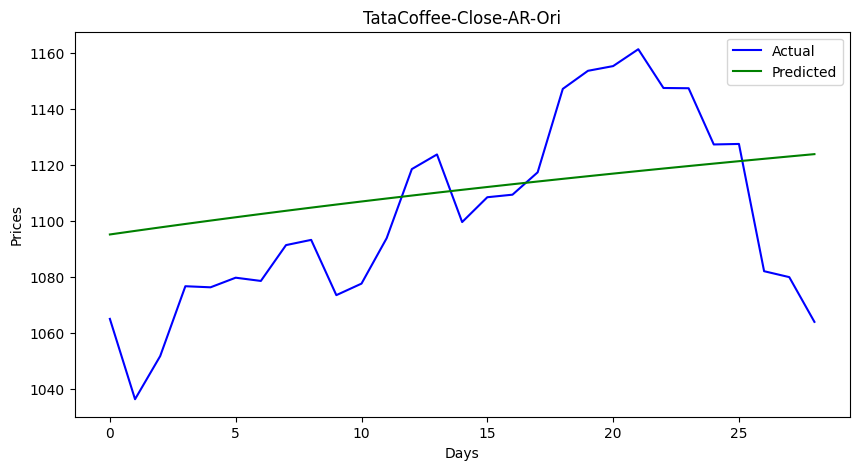

In [39]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","TataCoffee-Close-AR-Ori","Days","Prices")

In [41]:
def rmsemape(y_Test,predicted_stock_price_test_ori):
    from sklearn.metrics import mean_squared_error
    from sklearn.metrics import mean_absolute_percentage_error
    import numpy as np
    
    print("RMSE-Testset:", np.sqrt(mean_squared_error(y_Test,predicted_stock_price_test_ori)))
    print("MAPE-Testset:", mean_absolute_percentage_error(y_Test,predicted_stock_price_test_ori))

In [42]:
forecast=model_fit.predict(len(data1), len(data1)+3)

In [43]:
forecast

array([0.62642911, 0.62897027, 0.63147813, 0.63395356])

In [44]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [45]:
forecast_stock_price_test_oriF

,Closefore
0,1124.625524
1,1125.430917
2,1126.225754
3,1127.010314


In [46]:
forecast_stock_price_test_oriF.to_csv("CloseAR.csv",index=False)

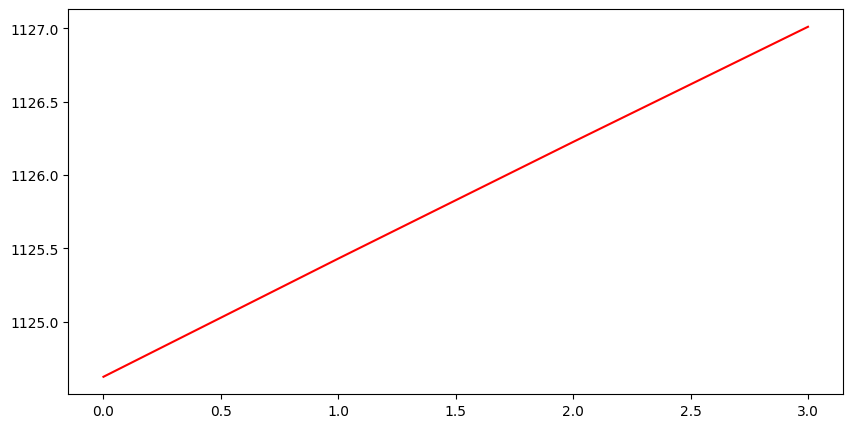

In [47]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(actual_stock_price_test_oriA[116:145], color = 'blue', label="Actual")
plt.plot(forecast_stock_price_test_oriF, color = 'red', label ="Predicted")